# Module 2 — Temporal & Demand Analysis

**Purpose:** Characterise demand dynamics at outlet × SKU × month grain and at national aggregation — trend, seasonality, stationarity, autocorrelation, and volatility. These properties directly determine which forecasting model class is appropriate and set the parameters for the buffer mechanism.

**Inputs:**
- `outlet_sku_monthly_demand.parquet` — aggregated to national SKU grain for time series tests
- `base_sales_enriched.parquet` — for return rate analysis

**Sections:**
1. National Trend Analysis
2. Seasonality Decomposition
3. Stationarity Testing
4. Autocorrelation Structure
5. Returns Over Time
6. SKU-Level Demand Analysis & Segmentation
7. Outlet–SKU Grain Characterisation
8. Demand Volatility for Buffer Sizing
9. Conclusion

In [12]:
import sys
from pathlib import Path

# PROJECT_ROOT = Path.cwd().parent.parent
PROJECT_ROOT = Path("../../..")
sys.path.insert(0, str(PROJECT_ROOT))

import warnings
warnings.filterwarnings("ignore")

import polars as pl
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
from statsmodels.tsa.seasonal import STL
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

from src.common.utils.config import load_config
from src.viz.mckinsey_theme import apply_mckinsey_theme, create_mckinsey_figure

apply_mckinsey_theme()

conf = load_config()
INTERMEDIATE = str(PROJECT_ROOT / conf["data"]["intermediate_path"])
print(f"Project root : {PROJECT_ROOT}")
print(f"Intermediate : {INTERMEDIATE}")

Project root : ../../..
Intermediate : ../../../data/Intermediate


In [13]:
osm = pl.read_parquet(f"{INTERMEDIATE}/outlet_sku_monthly_demand.parquet")
bse = pl.read_parquet(f"{INTERMEDIATE}/base_sales_enriched.parquet")

print(f"outlet_sku_monthly_demand : {osm.shape}")
print(f"base_sales_enriched       : {bse.shape}")
print(f"Date range (osm)          : {osm['year_month'].min()} → {osm['year_month'].max()}")
print(f"Unique SKUs               : {osm['item_code'].n_unique()}")
print(f"Unique outlets            : {osm['outlet_id'].n_unique()}")
display(osm.head(3).to_pandas())

outlet_sku_monthly_demand : (123104457, 18)
base_sales_enriched       : (6799893, 18)
Date range (osm)          : 2015-01 → 2020-03
Unique SKUs               : 50
Unique outlets            : 116014


,outlet_id,item_code,year_month,net_quantity,net_sales,gross_quantity,gross_sales,return_quantity,return_sales,n_invoices,n_returns,territory_id,region,district,province,product_category,product_line,brand
0,87771,pf0033301,2015-01,0,0.0,0,0.0,0,0.0,0,0,85,region_3,district_3,province_3,cat_2,prod_line3,brand_1
1,87771,pf0033301,2015-02,0,0.0,0,0.0,0,0.0,0,0,85,region_3,district_3,province_3,cat_2,prod_line3,brand_1
2,87771,pf0033301,2015-03,0,0.0,0,0.0,0,0.0,0,0,85,region_3,district_3,province_3,cat_2,prod_line3,brand_1


---
## 1 — National Trend Analysis

Aggregate all outlets and SKUs to a single monthly national series, overlay moving averages, and compute MoM and YoY growth rates to characterise structural trend direction.

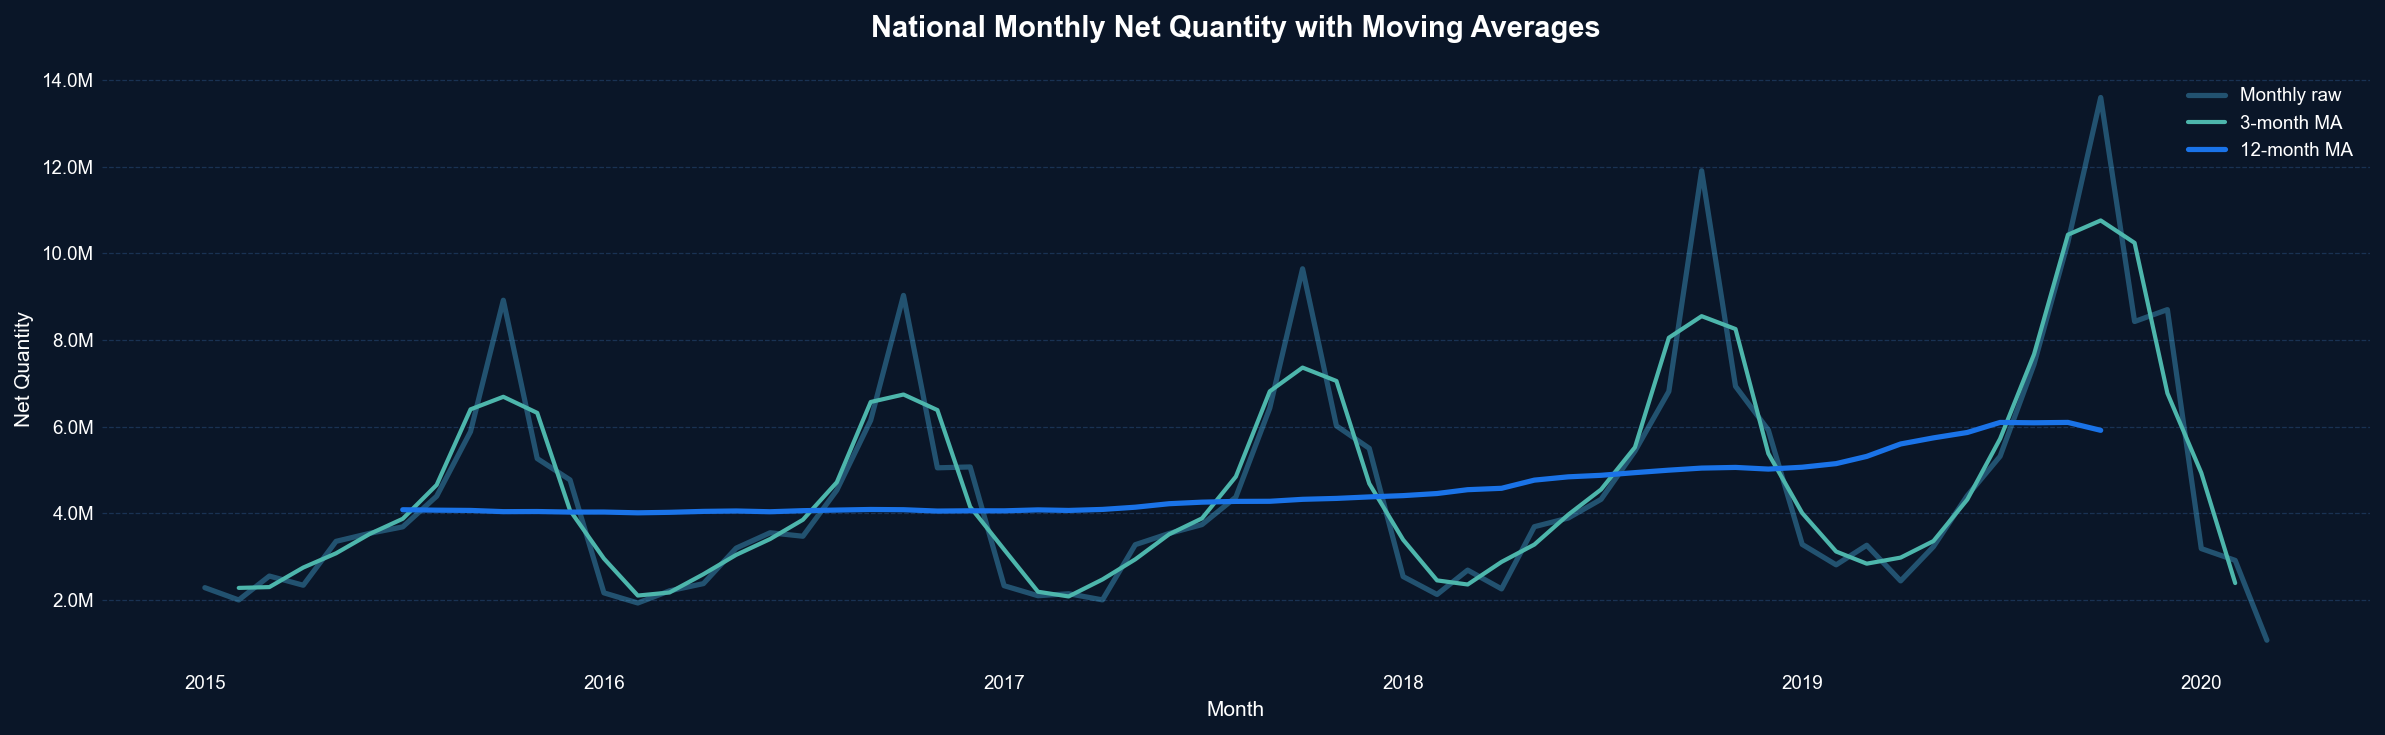

Analysis window : 2015-01 → 2020-03
Total months    : 63


In [14]:
national = (
    osm
    .group_by("year_month")
    .agg(
        pl.sum("net_quantity").alias("net_quantity"),
        pl.sum("net_sales").alias("net_sales"),
        pl.sum("gross_quantity").alias("gross_quantity"),
        pl.sum("return_quantity").alias("return_quantity"),
    )
    .sort("year_month")
    .to_pandas()
)
national["period"] = pd.to_datetime(national["year_month"], format="%Y-%m")
national = national.sort_values("period").reset_index(drop=True)

national["ma3"]  = national["net_quantity"].rolling(3,  center=True).mean()
national["ma12"] = national["net_quantity"].rolling(12, center=True).mean()

fig, ax = create_mckinsey_figure(figsize=(16, 5), title="National Monthly Net Quantity with Moving Averages")
ax.plot(national["period"], national["net_quantity"], alpha=0.35, label="Monthly raw")
ax.plot(national["period"], national["ma3"],  linewidth=2,   label="3-month MA")
ax.plot(national["period"], national["ma12"], linewidth=2.5, label="12-month MA")
ax.set_xlabel("Month")
ax.set_ylabel("Net Quantity")
ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f"{x/1e6:.1f}M" if x >= 1e6 else f"{x/1e3:.0f}K"))
ax.legend()
plt.tight_layout()
plt.show()

print(f"Analysis window : {national['period'].min().strftime('%Y-%m')} → {national['period'].max().strftime('%Y-%m')}")
print(f"Total months    : {len(national)}")

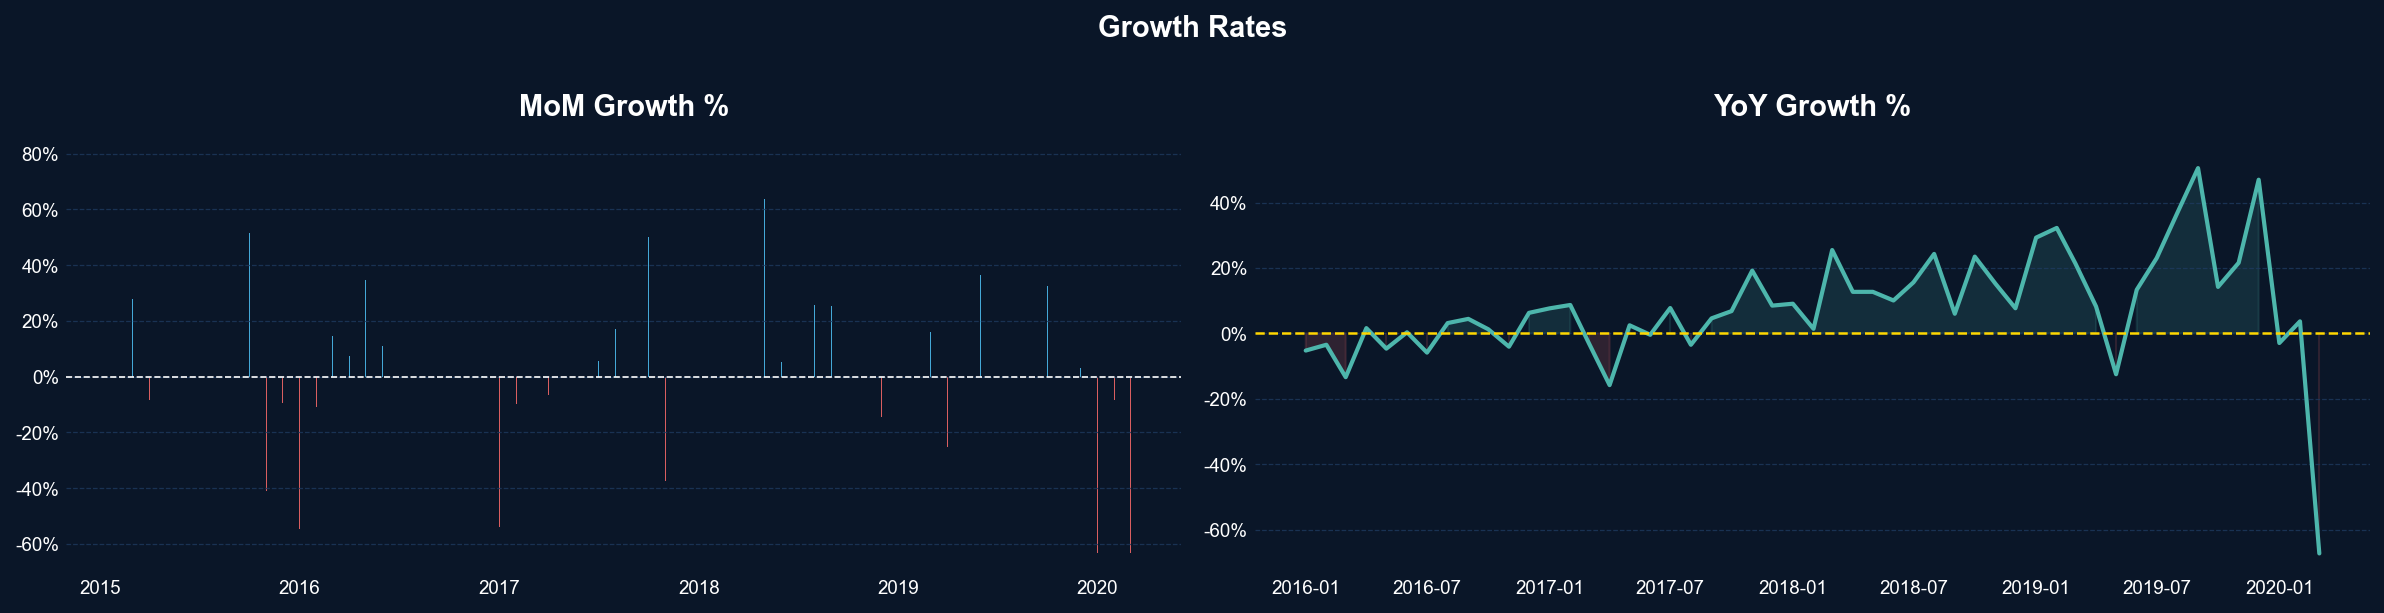

YoY growth — mean: 7.9%  median: 7.6%  min: -67.3%  max: 50.5%


In [15]:
national["mom_growth"] = national["net_quantity"].pct_change() * 100
national["yoy_growth"] = national["net_quantity"].pct_change(12) * 100

fig, axes = create_mckinsey_figure(1, 2, figsize=(16, 4))
fig.suptitle("Growth Rates", color="white", fontsize=14, fontweight="bold", y=1.01)

bar_colors = ["#4FC3F7" if v >= 0 else "#FF6B6B" for v in national["mom_growth"].fillna(0)]
axes[0].bar(national["period"], national["mom_growth"], color=bar_colors, alpha=0.85)
axes[0].axhline(0, color="white", linewidth=0.8, linestyle="--")
axes[0].set_title("MoM Growth %")
axes[0].yaxis.set_major_formatter(mtick.FormatStrFormatter("%.0f%%"))

axes[1].plot(national["period"], national["yoy_growth"], color="#4DB6AC", linewidth=2)
axes[1].axhline(0, color="#FFD600", linestyle="--", linewidth=1.2)
axes[1].fill_between(national["period"], national["yoy_growth"], 0,
                     where=(national["yoy_growth"] >= 0), alpha=0.15, color="#4DB6AC")
axes[1].fill_between(national["period"], national["yoy_growth"], 0,
                     where=(national["yoy_growth"] < 0),  alpha=0.15, color="#FF6B6B")
axes[1].set_title("YoY Growth %")
axes[1].yaxis.set_major_formatter(mtick.FormatStrFormatter("%.0f%%"))

plt.tight_layout()
plt.show()

yoy = national["yoy_growth"].dropna()
print(f"YoY growth — mean: {yoy.mean():.1f}%  median: {yoy.median():.1f}%  "
      f"min: {yoy.min():.1f}%  max: {yoy.max():.1f}%")

---
## 2 — Seasonality Decomposition

Apply STL (Seasonal-Trend decomposition using LOESS) with `period=12` on the national monthly series. Measure seasonal strength and build a month-of-year seasonal index.

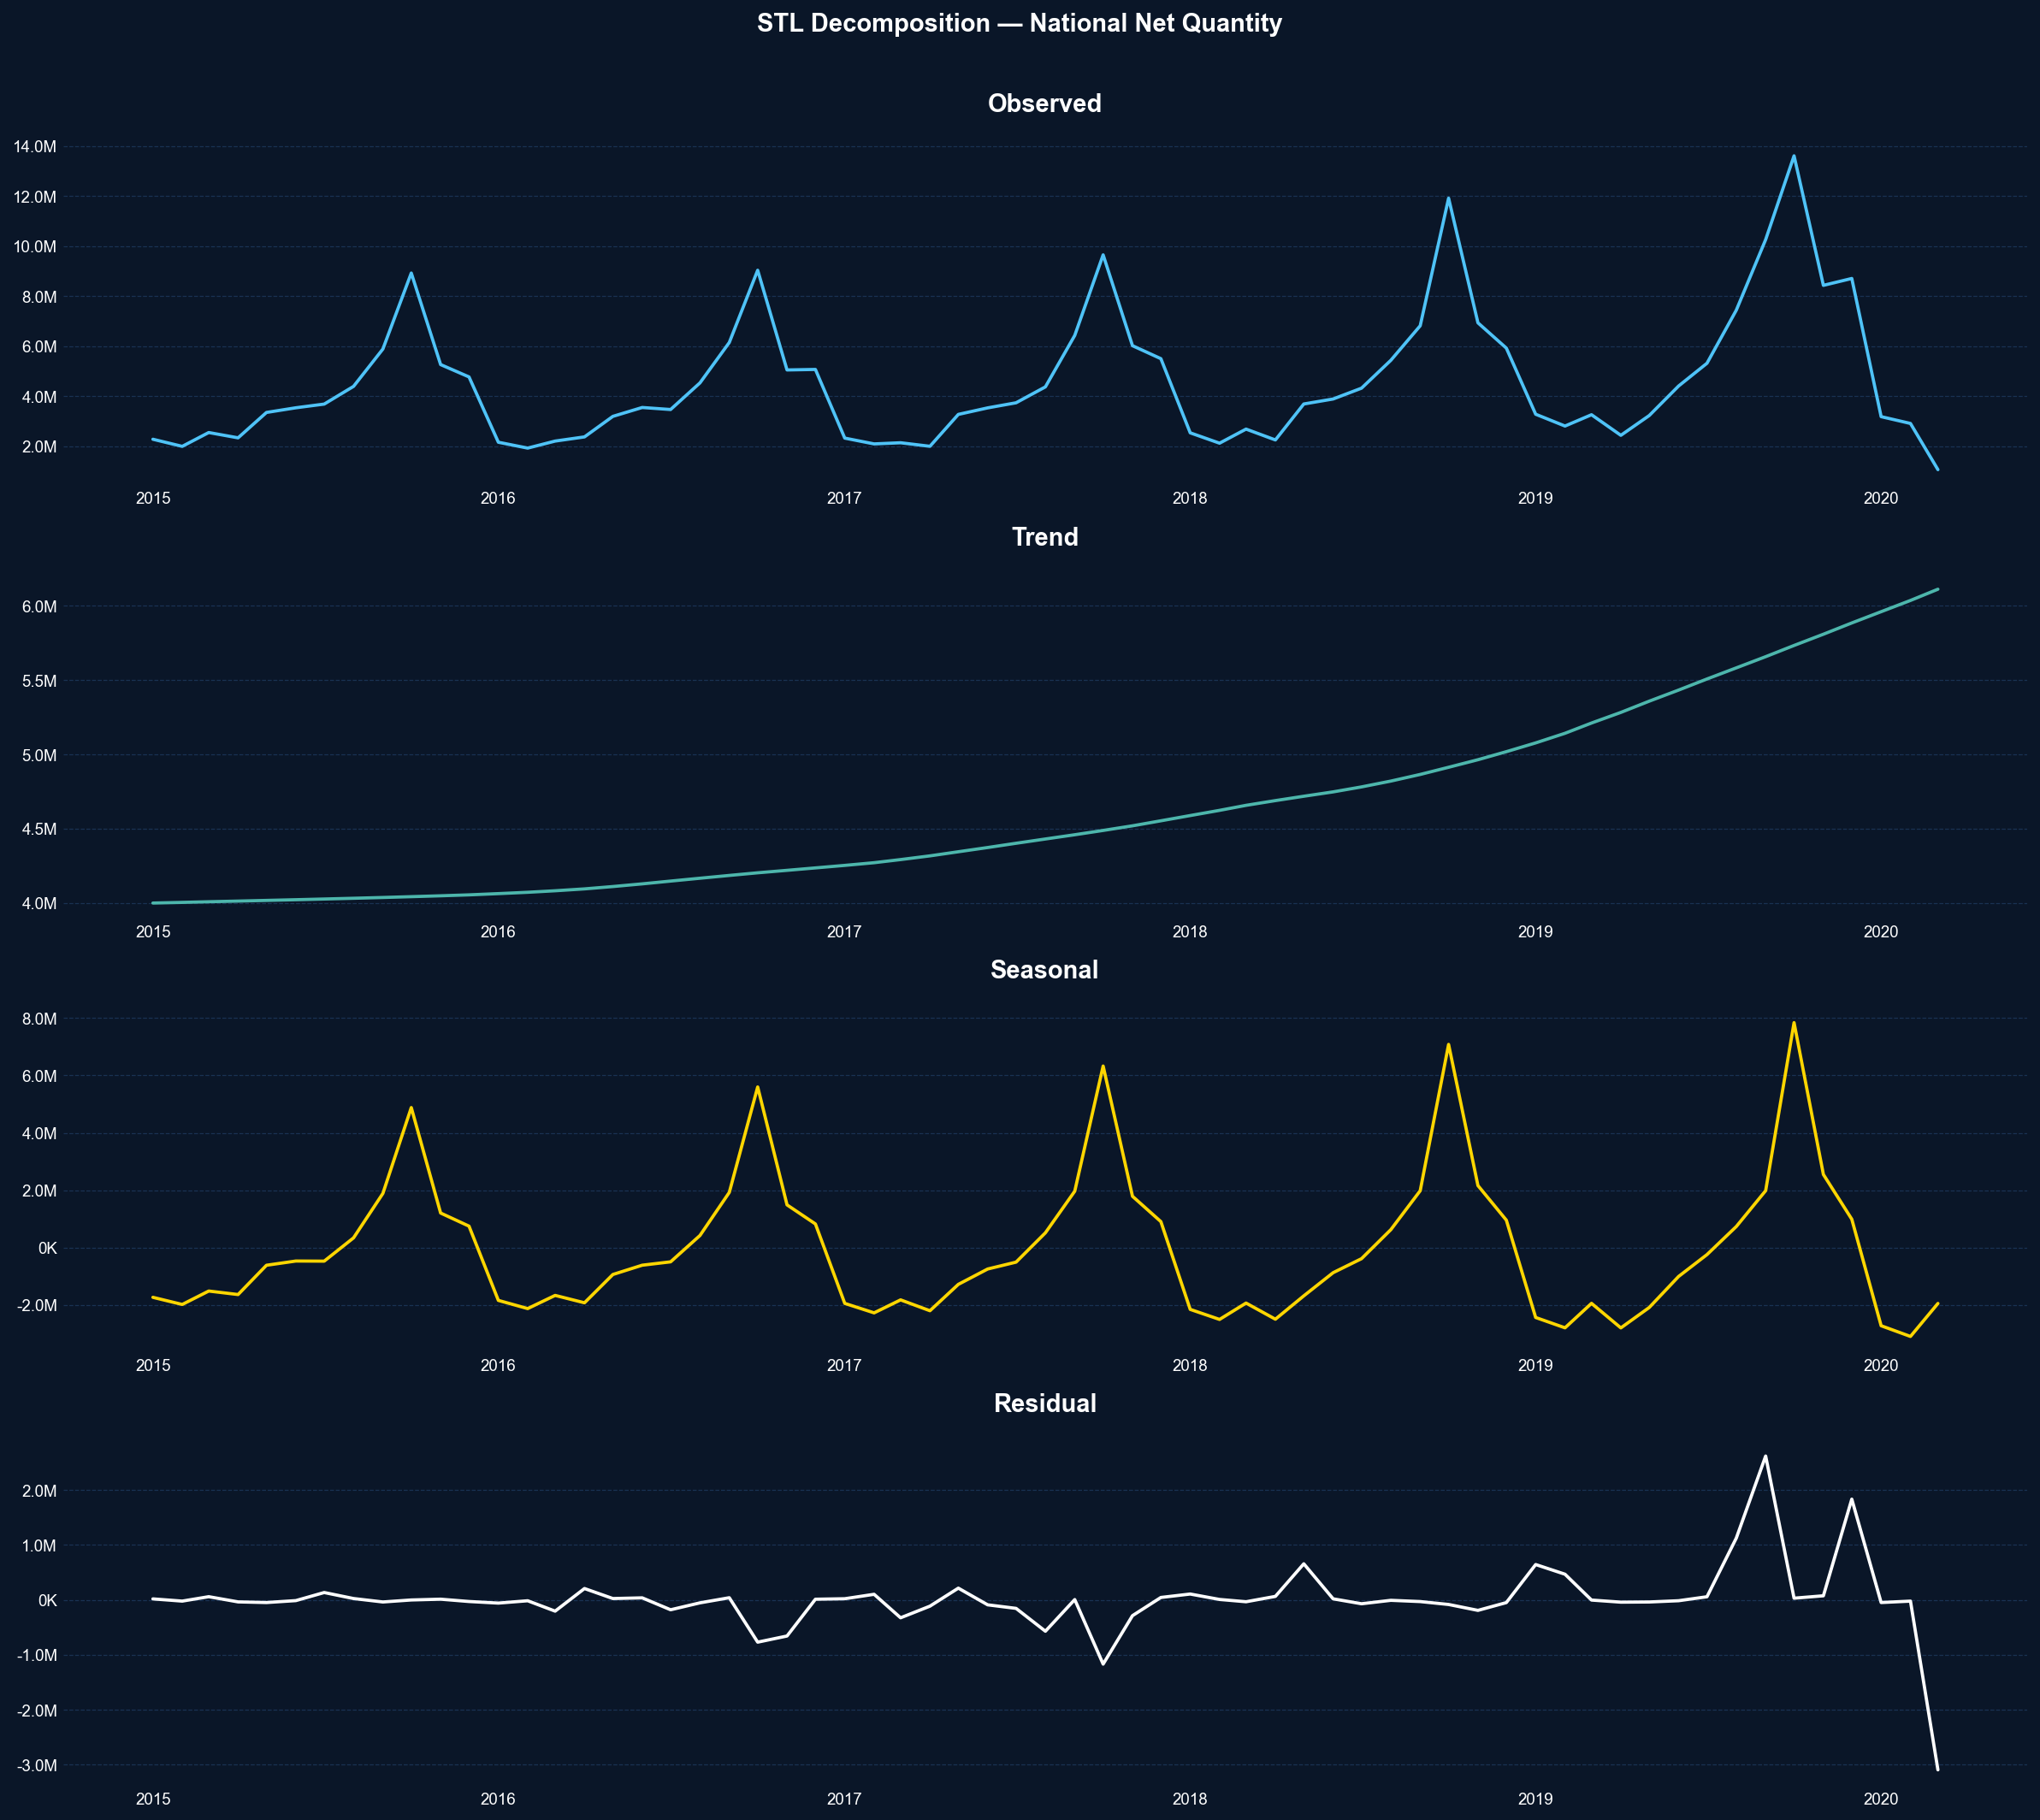

Seasonal strength : 0.936  (STRONG — must model explicitly)


In [16]:
ts = national.set_index("period")["net_quantity"].asfreq("MS").dropna()
stl = STL(ts, period=12, robust=True).fit()

fig, axes = create_mckinsey_figure(4, 1, figsize=(16, 14))
fig.suptitle("STL Decomposition — National Net Quantity", color="white",
             fontsize=14, fontweight="bold", y=1.01)

components = [
    (stl.observed,  "Observed",  "#4FC3F7"),
    (stl.trend,     "Trend",     "#4DB6AC"),
    (stl.seasonal,  "Seasonal",  "#FFD600"),
    (stl.resid,     "Residual",  "#FFFFFF"),
]
for ax, (data, label, color) in zip(axes, components):
    ax.plot(ts.index, data, color=color, linewidth=1.8)
    ax.set_title(label)
    ax.yaxis.set_major_formatter(mtick.FuncFormatter(
        lambda x, _: f"{x/1e6:.1f}M" if abs(x) >= 1e6 else f"{x/1e3:.0f}K"
    ))

plt.tight_layout()
plt.show()

var_s = float(np.var(stl.seasonal))
var_r = float(np.var(stl.resid))
seasonal_strength = var_s / (var_s + var_r)
verdict = "STRONG — must model explicitly" if seasonal_strength > 0.6 else "WEAK — may be omitted"
print(f"Seasonal strength : {seasonal_strength:.3f}  ({verdict})")

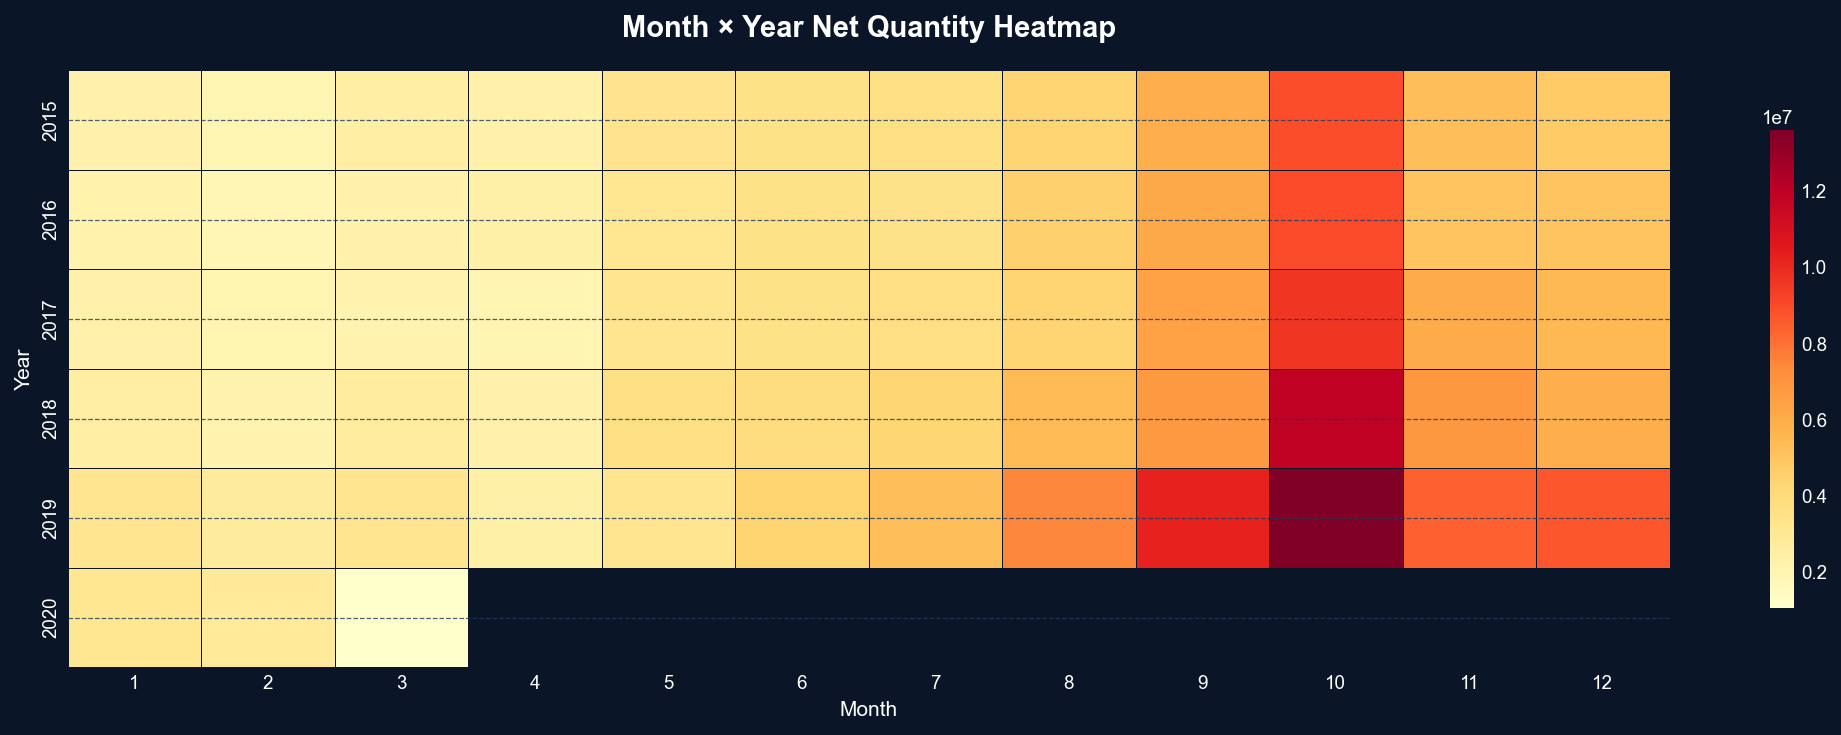

,Month,Index (1.0 = average)
9,Oct,2.326947
8,Sep,1.556626
10,Nov,1.388426
11,Dec,1.312780
7,Aug,1.146669
6,Jul,0.899416
5,Jun,0.828757
4,May,0.733271
0,Jan,0.575744
2,Mar,0.507887


Peak month: Oct  |  Trough month: Apr


In [17]:
national["month"] = national["period"].dt.month
national["year"]  = national["period"].dt.year
pivot = national.pivot_table(index="year", columns="month", values="net_quantity")

fig, ax = create_mckinsey_figure(figsize=(14, 5), title="Month × Year Net Quantity Heatmap")
sns.heatmap(
    pivot, ax=ax, cmap="YlOrRd",
    linewidths=0.4, linecolor="#0A1628",
    fmt=".0f", annot=False,
    cbar_kws={"shrink": 0.8}
)
ax.set_xlabel("Month")
ax.set_ylabel("Year")
plt.tight_layout()
plt.show()

global_mean    = national["net_quantity"].mean()
monthly_mean   = national.groupby("month")["net_quantity"].mean()
seasonal_index = (monthly_mean / global_mean).rename("seasonal_index").reset_index()
seasonal_index.columns = ["month", "seasonal_index"]
seasonal_index["month_name"] = pd.to_datetime(seasonal_index["month"], format="%m").dt.strftime("%b")
seasonal_index = seasonal_index.sort_values("seasonal_index", ascending=False)

display(seasonal_index[["month_name", "seasonal_index"]].rename(
    columns={"month_name": "Month", "seasonal_index": "Index (1.0 = average)"}
))

peak_month   = seasonal_index.iloc[0]["month_name"]
trough_month = seasonal_index.iloc[-1]["month_name"]
print(f"Peak month: {peak_month}  |  Trough month: {trough_month}")

---
## 3 — Stationarity Testing

Run ADF (H₀: unit root, non-stationary) and KPSS (H₀: stationary) on the national series at level and after first differencing to determine integration order `d`.

In [18]:
def run_adf(series, label):
    res = adfuller(series.dropna(), autolag="AIC")
    verdict = "REJECT H₀ → stationary" if res[1] < 0.05 else "FAIL TO REJECT H₀ → non-stationary"
    print(f"  ADF  [{label}]  stat={res[0]:8.3f}  p={res[1]:.4f}  → {verdict}")
    return res[1] < 0.05

def run_kpss(series, label):
    stat, p, _, _ = kpss(series.dropna(), regression="c", nlags="auto")
    verdict = "REJECT H₀ → non-stationary" if p < 0.05 else "FAIL TO REJECT H₀ → stationary"
    print(f"  KPSS [{label}]  stat={stat:8.3f}  p={p:.4f}  → {verdict}")
    return p >= 0.05

print("─── Level series ───")
adf_level  = run_adf(ts, "d=0")
kpss_level = run_kpss(ts, "d=0")

ts_d1 = ts.diff().dropna()
print("─── First-differenced series (d=1) ───")
adf_d1  = run_adf(ts_d1,  "d=1")
kpss_d1 = run_kpss(ts_d1, "d=1")

print()
if adf_d1 and kpss_d1:
    print("Verdict: I(1) — series becomes stationary after first differencing. Use d=1 in ARIMA.")
elif adf_level and kpss_level:
    print("Verdict: I(0) — series is stationary at level. Use d=0 in ARIMA.")
else:
    print("Verdict: Conflicting signals — may indicate trend-stationarity or fractional integration.")

─── Level series ───
  ADF  [d=0]  stat=   2.485  p=0.9990  → FAIL TO REJECT H₀ → non-stationary
  KPSS [d=0]  stat=   0.258  p=0.1000  → FAIL TO REJECT H₀ → stationary
─── First-differenced series (d=1) ───
  ADF  [d=1]  stat=  -3.168  p=0.0219  → REJECT H₀ → stationary
  KPSS [d=1]  stat=   0.059  p=0.1000  → FAIL TO REJECT H₀ → stationary

Verdict: I(1) — series becomes stationary after first differencing. Use d=1 in ARIMA.


---
## 4 — Autocorrelation Structure

Plot ACF and PACF on the first-differenced series to identify candidate AR and MA orders. Run Ljung-Box test at lags 6 and 12 to confirm exploitable autocorrelation structure.

ValueError: Can only compute partial correlations for lags up to 50% of the sample size. The requested nlags 36 must be < 31.

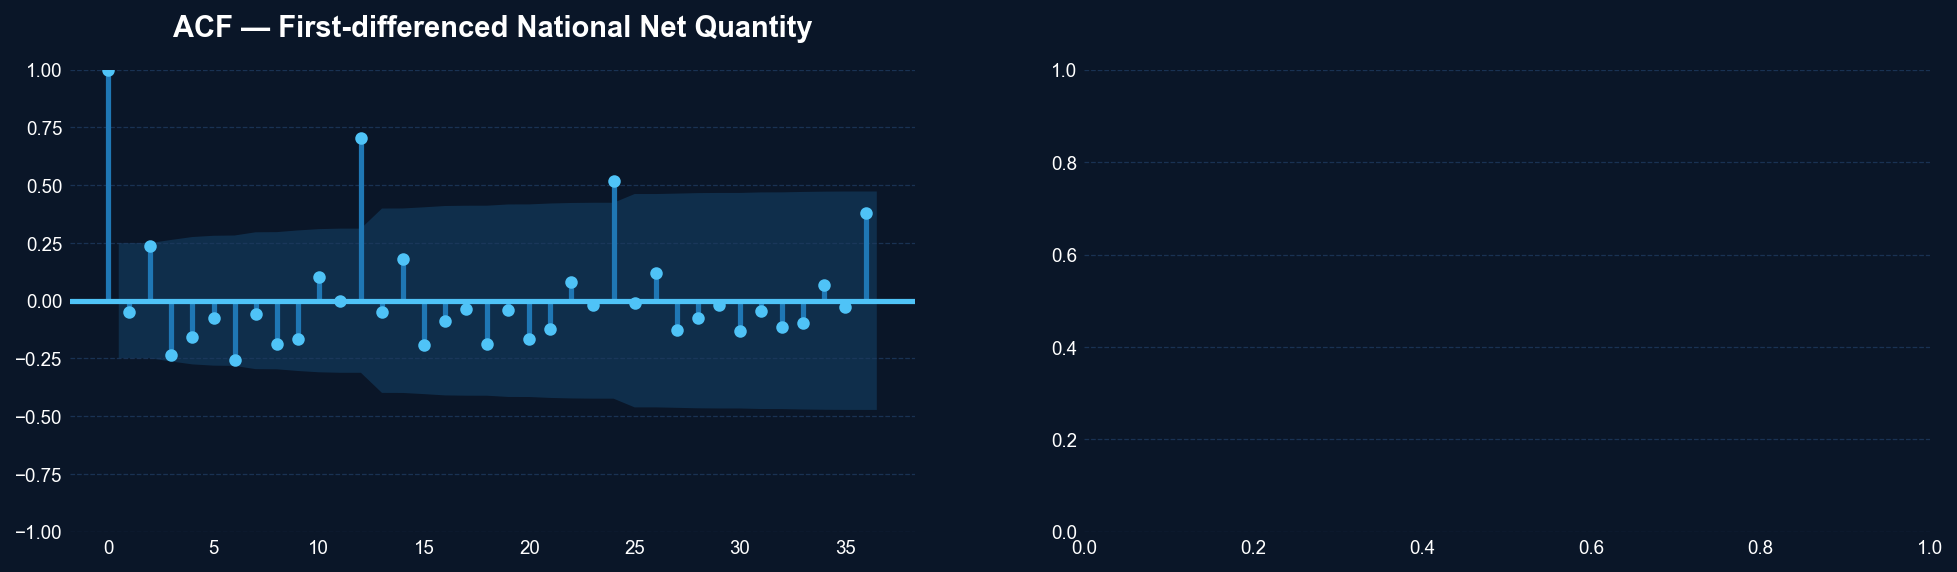

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(16, 4),
                         facecolor="#0A1628")
fig.patch.set_facecolor("#0A1628")

for ax in axes:
    ax.set_facecolor("#0A1628")
    ax.tick_params(colors="white")
    ax.xaxis.label.set_color("white")
    ax.yaxis.label.set_color("white")
    ax.title.set_color("white")
    for spine in ax.spines.values():
        spine.set_color("#1E3A5F")

plot_acf( ts_d1, lags=36, ax=axes[0], color="#4FC3F7",
          title="ACF — First-differenced National Net Quantity")
plot_pacf(ts_d1, lags=36, ax=axes[1], color="#4DB6AC",
          title="PACF — First-differenced National Net Quantity")

plt.tight_layout()
plt.show()

lb = acorr_ljungbox(ts_d1, lags=[6, 12], return_df=True)
print("Ljung-Box test (H₀: residuals are white noise):")
display(lb.rename(columns={"lb_stat": "Q-stat", "lb_pvalue": "p-value"}))

if (lb["lb_pvalue"] < 0.05).any():
    print("→ Exploitable autocorrelation structure exists — model with AR/MA terms.")
else:
    print("→ White noise at tested lags — no exploitable autocorrelation at lags 6 and 12.")

---
## 5 — Returns Over Time

Plot the monthly return rate (return quantity / gross invoice quantity) and identify anomaly months above the 95th percentile threshold.

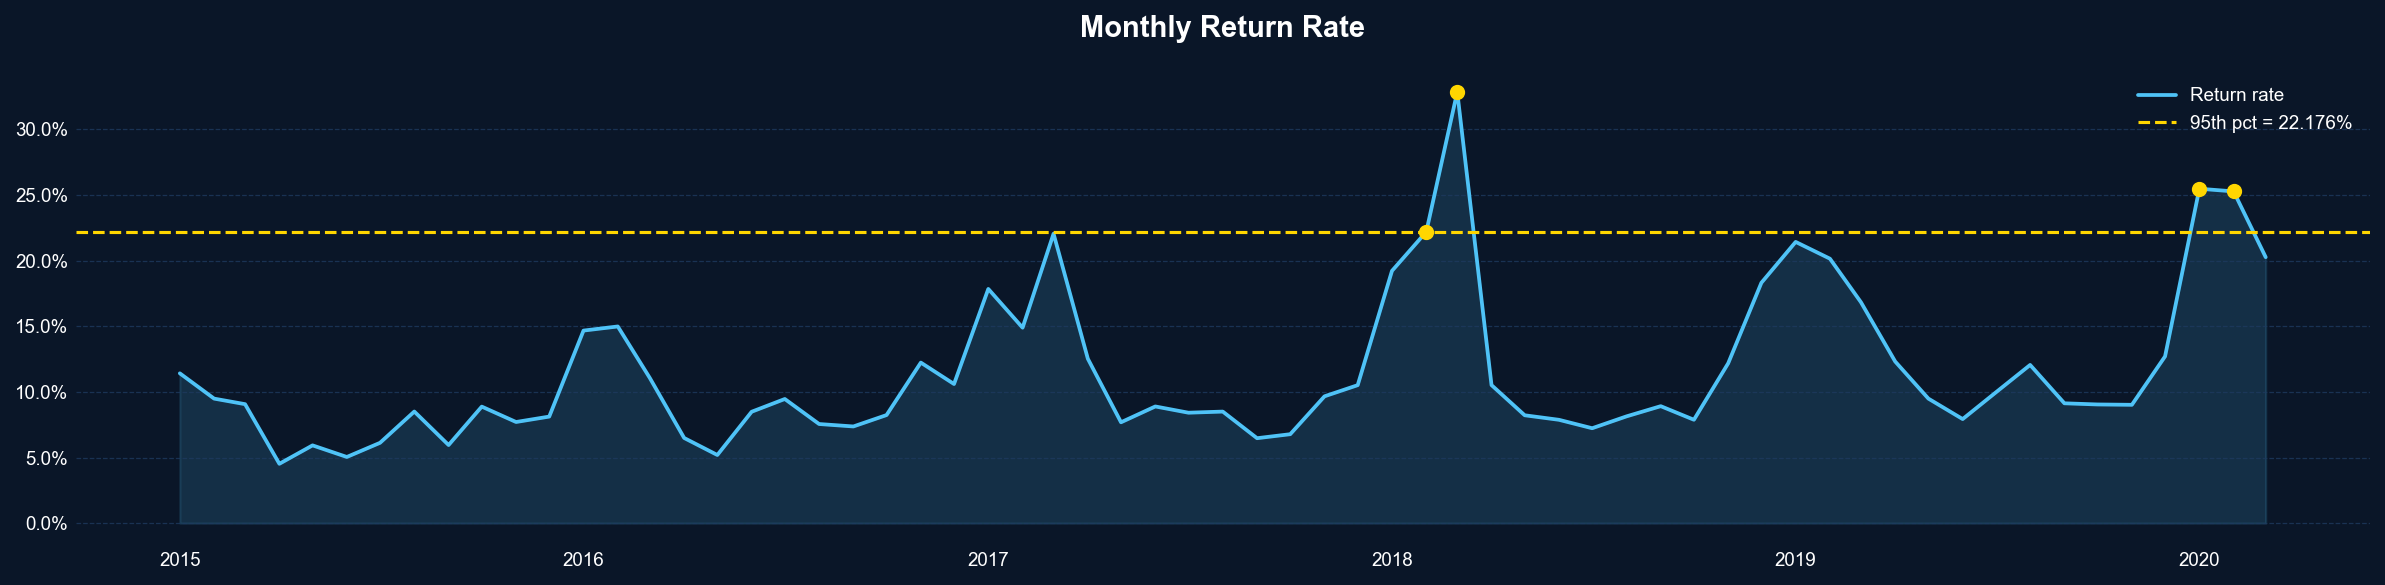

Overall return rate  : 10.697%
95th pct threshold   : 22.176%
Anomaly months (>22.176%): 4


,year_month,return_rate_%
37,2018-02,22.19
38,2018-03,32.85
60,2020-01,25.47
61,2020-02,25.27


In [20]:
returns_monthly = (
    bse.filter(pl.col("document_type") == "return")
       .group_by("year_month")
       .agg(pl.col("quantity").abs().sum().alias("return_qty"))
)
invoices_monthly = (
    bse.filter(pl.col("document_type") == "invoice")
       .group_by("year_month")
       .agg(pl.col("quantity").sum().alias("invoice_qty"))
)
return_df = (
    invoices_monthly
    .join(returns_monthly, on="year_month", how="left")
    .with_columns(pl.col("return_qty").fill_null(0))
    .with_columns(
        (pl.col("return_qty") / pl.col("invoice_qty")).alias("return_rate")
    )
    .sort("year_month")
    .to_pandas()
)
return_df["period"] = pd.to_datetime(return_df["year_month"], format="%Y-%m")

p95 = return_df["return_rate"].quantile(0.95)
anomaly = return_df[return_df["return_rate"] > p95]

fig, ax = create_mckinsey_figure(figsize=(16, 4), title="Monthly Return Rate")
ax.plot(return_df["period"], return_df["return_rate"],
        color="#4FC3F7", linewidth=1.8, label="Return rate")
ax.fill_between(return_df["period"], return_df["return_rate"],
                alpha=0.15, color="#4FC3F7")
ax.axhline(p95, color="#FFD600", linestyle="--", linewidth=1.5,
           label=f"95th pct = {p95:.3%}")
ax.scatter(anomaly["period"], anomaly["return_rate"],
           color="#FFD600", zorder=5, s=40)
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax.legend()
plt.tight_layout()
plt.show()

overall_return_rate = return_df["return_qty"].sum() / return_df["invoice_qty"].sum()
print(f"Overall return rate  : {overall_return_rate:.3%}")
print(f"95th pct threshold   : {p95:.3%}")
print(f"Anomaly months (>{p95:.3%}): {len(anomaly)}")
if len(anomaly) > 0:
    display(anomaly[["year_month", "return_rate"]].rename(
        columns={"return_rate": "return_rate_%"}
    ).assign(**{"return_rate_%": lambda d: (d["return_rate_%"] * 100).round(2)})
    )

---
## 6 — SKU-Level Demand Analysis & Segmentation

Aggregate `outlet_sku_monthly_demand` to national SKU grain. Per SKU compute: active months, demand interval (Croston input), and coefficient of variation (CV). Segment into Continuous / Intermittent / Lumpy.

| Class | Criteria | Forecasting method |
|-------|----------|-------------------|
| **Continuous** | active ≥ 80% of months AND CV < 0.5 | ARIMA / ETS |
| **Lumpy** | active < 20% of months OR CV > 1.0 | Manual review / ADIDA |
| **Intermittent** | everything else | Croston / SBA |

In [21]:
n_months = osm.select("year_month").n_unique()
print(f"Total months in analysis window: {n_months}")

sku_national = (
    osm.group_by(["item_code", "year_month"])
       .agg(pl.sum("net_quantity").alias("net_quantity"))
)

sku_stats = (
    sku_national.group_by("item_code").agg([
        pl.col("net_quantity").filter(pl.col("net_quantity") > 0).len().alias("active_months"),
        pl.col("net_quantity").std().alias("std_qty"),
        pl.col("net_quantity").filter(pl.col("net_quantity") > 0).mean().alias("mean_active_qty"),
        pl.sum("net_quantity").alias("total_net_quantity"),
    ])
    .with_columns([
        (pl.col("active_months") / n_months).alias("active_frac"),
        (pl.col("std_qty") / pl.col("mean_active_qty")).alias("cv"),
        (pl.lit(n_months) / pl.col("active_months").clip(lower_bound=1)).alias("demand_interval"),
    ])
    .to_pandas()
)

display(sku_stats.describe().round(3))

Total months in analysis window: 63


,active_months,std_qty,mean_active_qty,total_net_quantity,active_frac,cv,demand_interval
count,50.000,50.000,50.000,5.000000e+01,50.000,50.000,50.000
mean,53.760,77333.039,118454.998,5.751993e+06,0.853,0.748,1.487
std,15.928,131883.873,207895.006,8.635130e+06,0.253,0.256,1.261
min,9.000,221.480,166.377,8.818000e+03,0.143,0.208,1.000
25%,48.500,8888.476,10194.286,6.060932e+05,0.770,0.563,1.000
50%,63.000,26289.253,36674.530,1.954037e+06,1.000,0.792,1.000
75%,63.000,74244.032,108454.080,5.638395e+06,1.000,0.877,1.302
max,63.000,618222.746,1040271.333,4.495642e+07,1.000,1.331,7.000


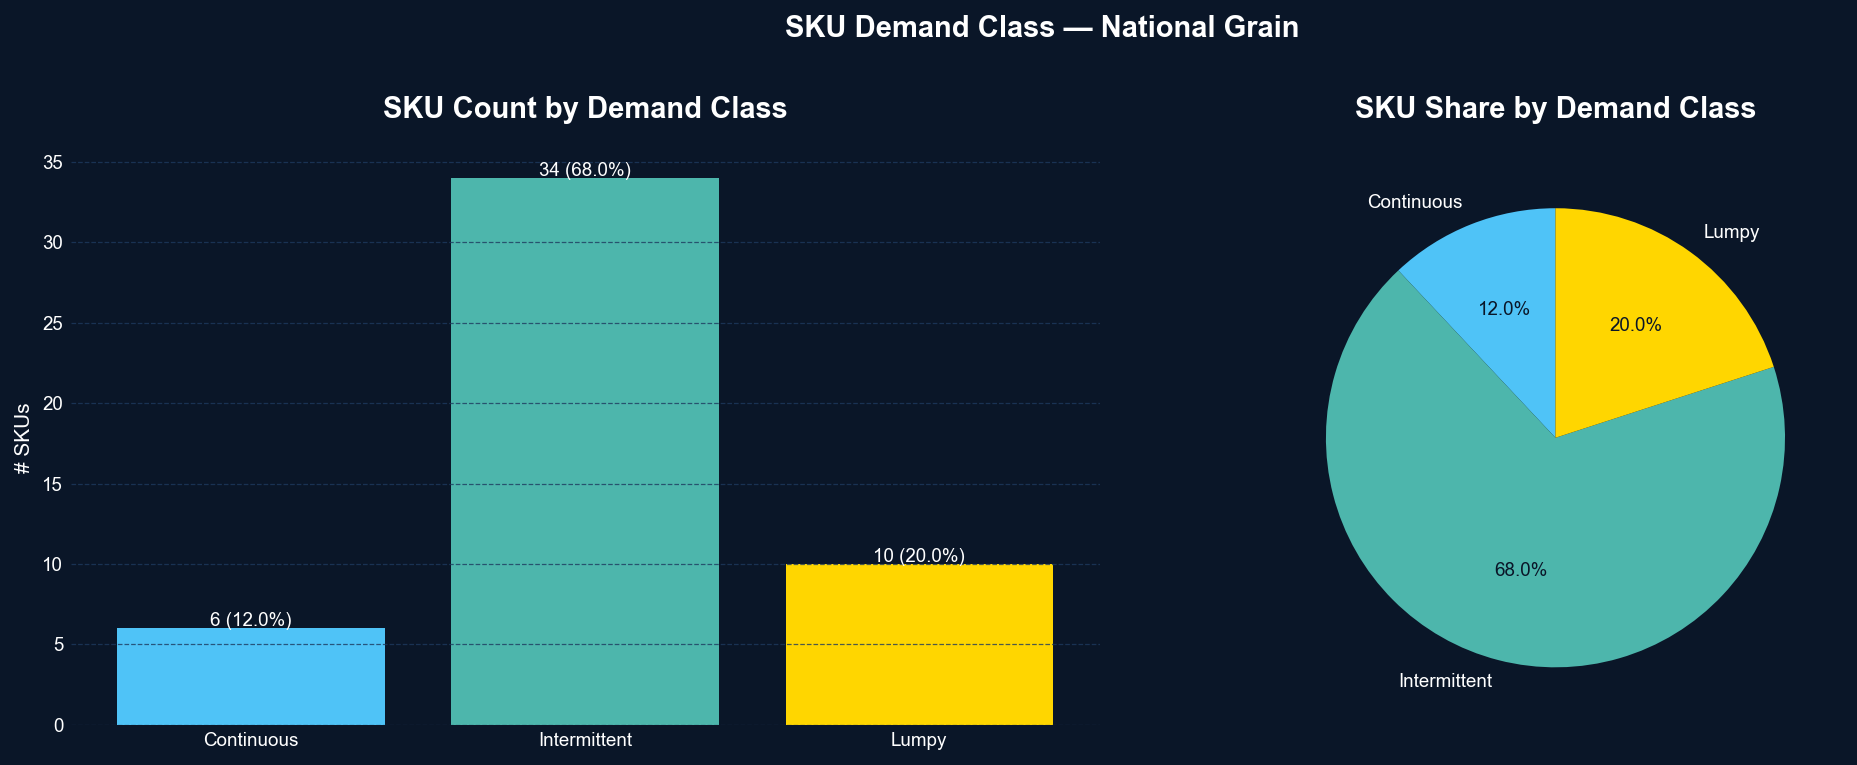

,demand_class,count,pct
2,Continuous,6,12.0
0,Intermittent,34,68.0
1,Lumpy,10,20.0



SKU detail by demand class:


active_frac                                               cv  \
                   count   mean    std    min    25%  50%  75%  max count   
demand_class                                                                
Continuous           6.0  1.000  0.000  1.000  1.000  1.0  1.0  1.0   6.0   
Intermittent        34.0  0.841  0.237  0.317  0.663  1.0  1.0  1.0  34.0   
Lumpy               10.0  0.806  0.353  0.143  0.865  1.0  1.0  1.0  10.0   

                     ... demand_interval       total_net_quantity  \
               mean  ...             75%   max              count   
demand_class         ...                                            
Continuous    0.321  ...           1.000  1.00                6.0   
Intermittent  0.747  ...           1.510  3.15               34.0   
Lumpy         1.010  ...           1.158  7.00               10.0   

                                                                          \
                     mean           std       min         25%        50%   
demand_class                                                               
Continuous    7662953.500  1.046781e+07  369723.0   837778.00  1954037.0   
Intermittent  5935057.324  9.010717e+06   26604.0  1149804.50  2477356.0   
Lumpy         3982997.900  6.430134e+06    8818.0   250524.75   615574.5   

                                       
                      75%         max  
demand_class                           
Continuous    12505364.25  25211759.0  
Intermittent   5638395.25  44956423.0  
Lumpy          4606863.00  20140658.0  

[3 rows x 32 columns]

In [22]:
def classify_sku(row):
    if row["active_frac"] >= 0.8 and row["cv"] < 0.5:
        return "Continuous"
    elif row["active_frac"] < 0.2 or row["cv"] > 1.0:
        return "Lumpy"
    else:
        return "Intermittent"

sku_stats["demand_class"] = sku_stats.apply(classify_sku, axis=1)
class_counts = sku_stats["demand_class"].value_counts().reset_index()
class_counts.columns = ["demand_class", "count"]
class_counts["pct"] = (class_counts["count"] / class_counts["count"].sum() * 100).round(1)

CLASS_COLORS = {"Continuous": "#4FC3F7", "Intermittent": "#4DB6AC", "Lumpy": "#FFD600"}
ORDER = ["Continuous", "Intermittent", "Lumpy"]
class_counts["demand_class"] = pd.Categorical(class_counts["demand_class"], categories=ORDER, ordered=True)
class_counts = class_counts.sort_values("demand_class")

fig, axes = create_mckinsey_figure(1, 2, figsize=(14, 5))
fig.suptitle("SKU Demand Class — National Grain", color="white",
             fontsize=14, fontweight="bold", y=1.01)

bar_colors = [CLASS_COLORS[c] for c in class_counts["demand_class"]]
axes[0].bar(class_counts["demand_class"], class_counts["count"], color=bar_colors)
for i, row in class_counts.reset_index(drop=True).iterrows():
    axes[0].text(i, row["count"] + 0.15, f"{row['count']} ({row['pct']}%)",
                 ha="center", color="white", fontsize=9)
axes[0].set_title("SKU Count by Demand Class")
axes[0].set_ylabel("# SKUs")

wedges, texts, autotexts = axes[1].pie(
    class_counts["count"],
    labels=class_counts["demand_class"],
    colors=bar_colors,
    autopct="%1.1f%%",
    startangle=90,
    textprops={"color": "white", "fontsize": 9},
)
for at in autotexts:
    at.set_color("#0A1628")
axes[1].set_facecolor("#0A1628")
axes[1].set_title("SKU Share by Demand Class")

plt.tight_layout()
plt.show()

display(class_counts)
print("\nSKU detail by demand class:")
display(sku_stats.groupby("demand_class")[["active_frac", "cv", "demand_interval", "total_net_quantity"]].describe().round(3))

---
## 7 — Outlet–SKU Grain Characterisation

Repeat the demand class analysis at the outlet × SKU pair level — the grain at which forecasts will actually be produced. This reveals the true distribution of demand sparsity that the forecasting pipeline must handle.

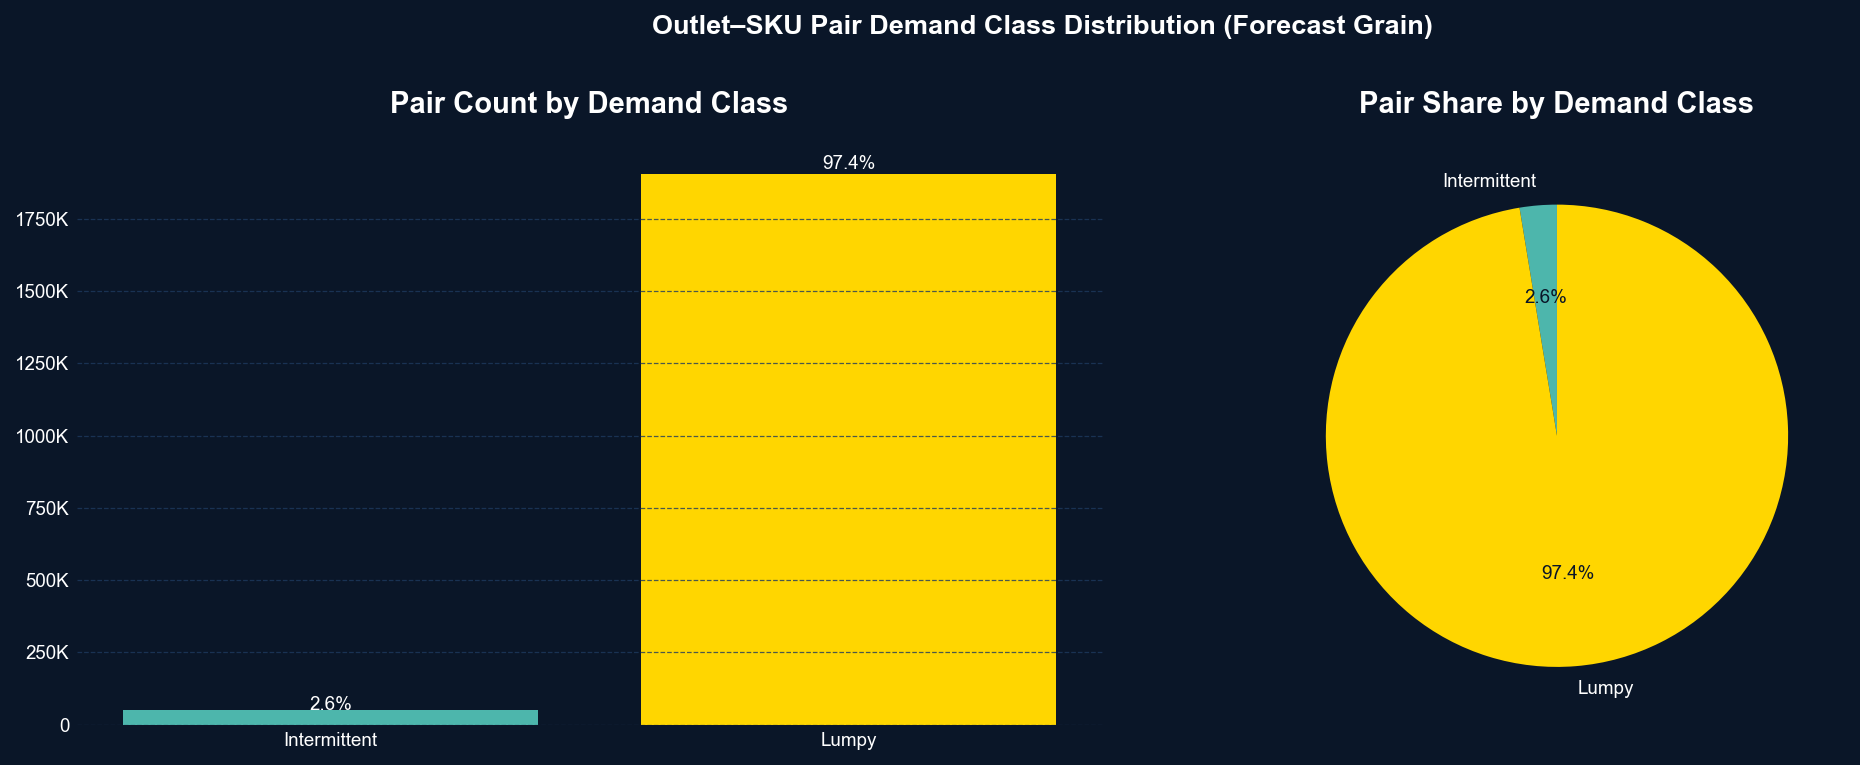

Total outlet–SKU pairs: 1,954,039


,demand_class,count,pct
1,Intermittent,50648,2.6
0,Lumpy,1903391,97.4


In [23]:
pair_stats = (
    osm.group_by(["outlet_id", "item_code"]).agg([
        pl.col("net_quantity").filter(pl.col("net_quantity") > 0).len().alias("active_months"),
        pl.col("net_quantity").std().alias("std_qty"),
        pl.col("net_quantity").filter(pl.col("net_quantity") > 0).mean().alias("mean_active_qty"),
    ])
    .with_columns([
        (pl.col("active_months") / n_months).alias("active_frac"),
        (pl.col("std_qty") / pl.col("mean_active_qty")).alias("cv"),
    ])
    .to_pandas()
)

pair_stats["demand_class"] = pair_stats.apply(classify_sku, axis=1)

pair_class_counts = pair_stats["demand_class"].value_counts().reset_index()
pair_class_counts.columns = ["demand_class", "count"]
pair_class_counts["pct"] = (pair_class_counts["count"] / pair_class_counts["count"].sum() * 100).round(1)

pair_class_counts["demand_class"] = pd.Categorical(
    pair_class_counts["demand_class"], categories=ORDER, ordered=True
)
pair_class_counts = pair_class_counts.sort_values("demand_class")

fig, axes = create_mckinsey_figure(1, 2, figsize=(14, 5))
fig.suptitle("Outlet–SKU Pair Demand Class Distribution (Forecast Grain)",
             color="white", fontsize=13, fontweight="bold", y=1.01)

bar_colors_p = [CLASS_COLORS[c] for c in pair_class_counts["demand_class"]]
axes[0].bar(pair_class_counts["demand_class"], pair_class_counts["count"], color=bar_colors_p)
for i, row in pair_class_counts.reset_index(drop=True).iterrows():
    axes[0].text(i, row["count"] * 1.01, f"{row['pct']}%",
                 ha="center", color="white", fontsize=9)
axes[0].set_title("Pair Count by Demand Class")
axes[0].yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f"{x/1e3:.0f}K" if x >= 1000 else str(int(x))))

wedges2, texts2, autotexts2 = axes[1].pie(
    pair_class_counts["count"],
    labels=pair_class_counts["demand_class"],
    colors=bar_colors_p,
    autopct="%1.1f%%",
    startangle=90,
    textprops={"color": "white", "fontsize": 9},
)
for at in autotexts2:
    at.set_color("#0A1628")
axes[1].set_facecolor("#0A1628")
axes[1].set_title("Pair Share by Demand Class")

plt.tight_layout()
plt.show()

print(f"Total outlet–SKU pairs: {len(pair_stats):,}")
display(pair_class_counts)

---
## 8 — Demand Volatility for Buffer Sizing

Segment SKUs by CV tier and compute the 90th percentile CV — the worst-case assumption for buffer sizing.

Safety stock formula: `SS = Z × σ_demand × √lead_time`

The `σ_demand` per SKU is the direct output this section feeds to the buffer model.

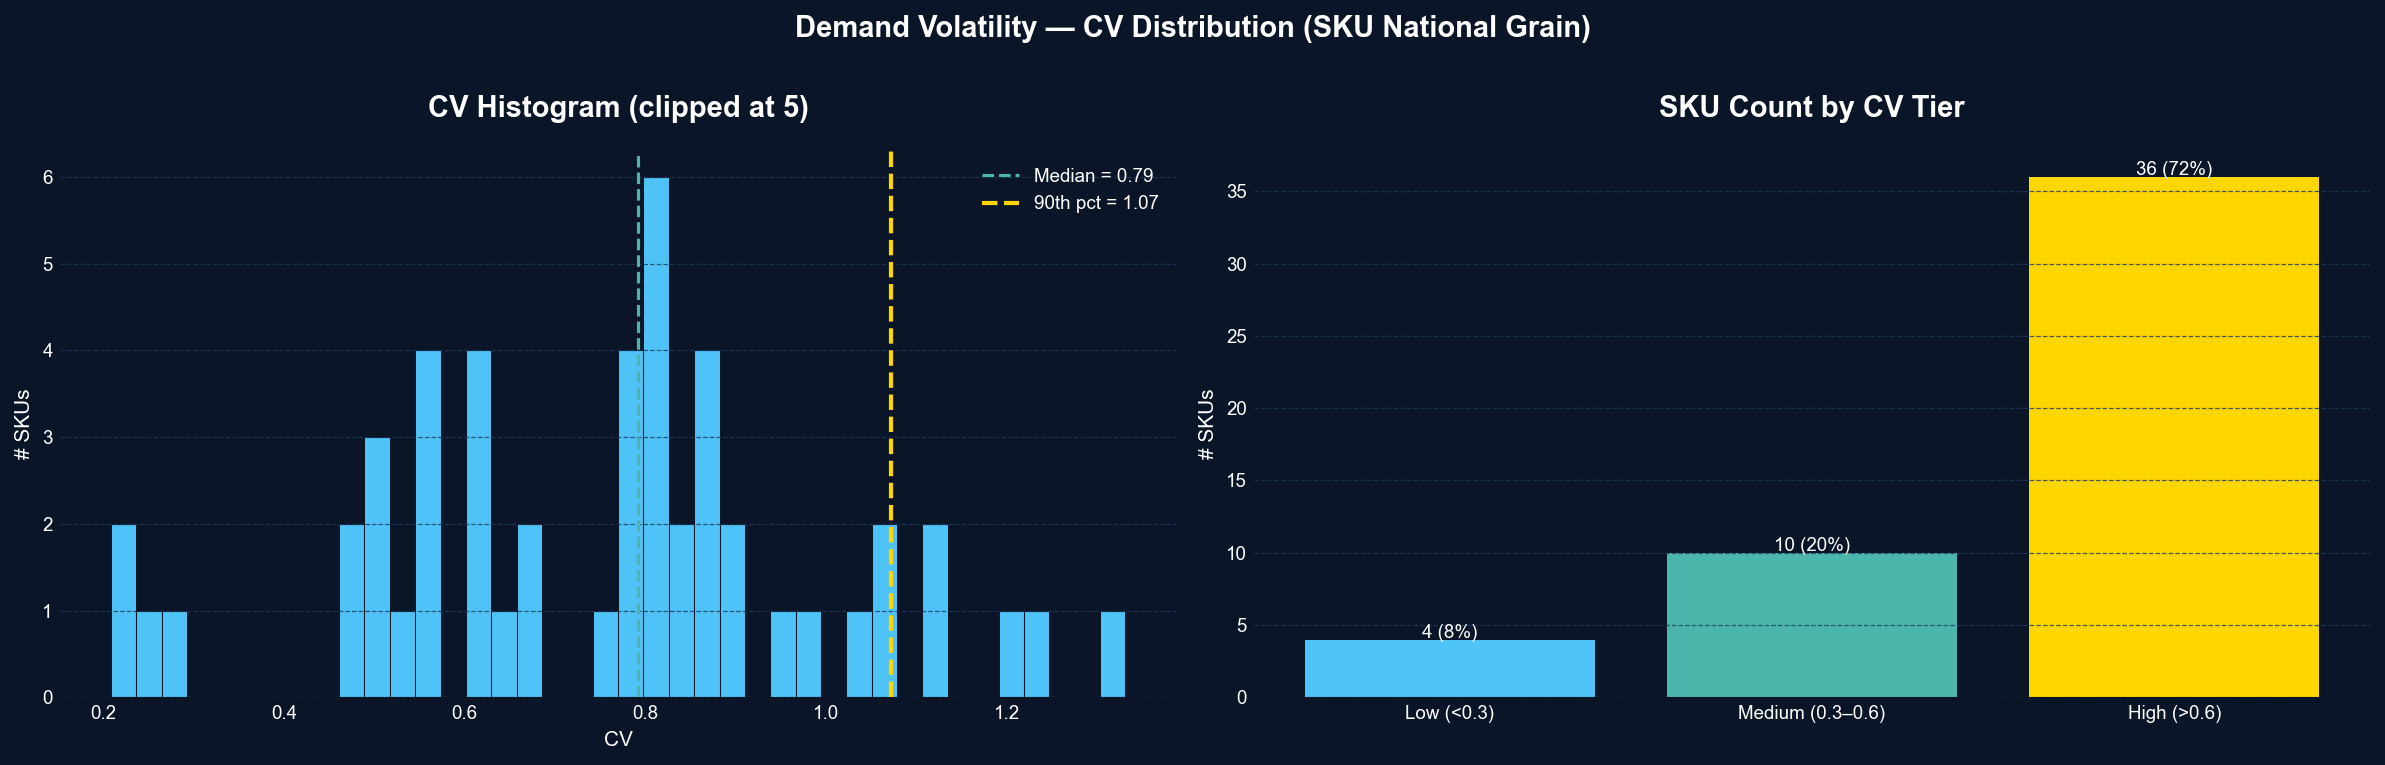

CV summary — mean: 0.748  |  median: 0.792  |  90th pct: 1.072
90th pct CV (1.07) → high-CV SKUs require ~3.6× more safety stock than a Low-CV SKU (CV=0.3) at the same service level.


cv                                                   \
                 count   mean    std    min    25%    50%    75%    max   
cv_tier                                                                   
High (>0.6)       36.0  0.868  0.180  0.612  0.784  0.830  0.951  1.331   
Low (<0.3)         4.0  0.239  0.028  0.208  0.226  0.237  0.250  0.275   
Medium (0.3–0.6)  10.0  0.520  0.037  0.472  0.492  0.517  0.550  0.573   

                 active_frac         ...           total_net_quantity  \
                       count   mean  ...  75%  max              count   
cv_tier                              ...                                
High (>0.6)             36.0  0.844  ...  1.0  1.0               36.0   
Low (<0.3)               4.0  1.000  ...  1.0  1.0                4.0   
Medium (0.3–0.6)        10.0  0.829  ...  1.0  1.0               10.0   

                                                                     \
                          mean           std        min         25%   
cv_tier                                                               
High (>0.6)       5.550809e+06  9.228697e+06     8818.0   574105.50   
Low (<0.3)        1.128443e+07  1.140890e+07  1940287.0  1960912.00   
Medium (0.3–0.6)  4.263280e+06  3.890982e+06    52513.0   723898.75   

                                                      
                        50%          75%         max  
cv_tier                                               
High (>0.6)       1852721.5   5150115.25  44956423.0  
Low (<0.3)        8992838.5  18316357.25  25211759.0  
Medium (0.3–0.6)  3657806.0   7418370.50  10166527.0  

[3 rows x 24 columns]

In [24]:
def cv_tier(cv):
    if pd.isna(cv):    return "N/A"
    if cv < 0.3:       return "Low (<0.3)"
    elif cv < 0.6:     return "Medium (0.3–0.6)"
    else:              return "High (>0.6)"

sku_stats["cv_tier"] = sku_stats["cv"].apply(cv_tier)

cv_clean = sku_stats["cv"].dropna()
p90_cv   = cv_clean.quantile(0.90)
p50_cv   = cv_clean.quantile(0.50)
mean_cv  = cv_clean.mean()

tier_order  = ["Low (<0.3)", "Medium (0.3–0.6)", "High (>0.6)"]
tier_colors = {"Low (<0.3)": "#4FC3F7", "Medium (0.3–0.6)": "#4DB6AC", "High (>0.6)": "#FFD600"}
tier_counts = sku_stats["cv_tier"].value_counts()

fig, axes = create_mckinsey_figure(1, 2, figsize=(16, 5))
fig.suptitle("Demand Volatility — CV Distribution (SKU National Grain)",
             color="white", fontsize=14, fontweight="bold", y=1.01)

cv_plot = cv_clean.clip(upper=5)
axes[0].hist(cv_plot, bins=40, color="#4FC3F7", edgecolor="#0A1628", linewidth=0.5)
axes[0].axvline(p50_cv,  color="#4DB6AC", linewidth=1.5, linestyle="--", label=f"Median = {p50_cv:.2f}")
axes[0].axvline(p90_cv,  color="#FFD600", linewidth=2,   linestyle="--", label=f"90th pct = {p90_cv:.2f}")
axes[0].set_title("CV Histogram (clipped at 5)")
axes[0].set_xlabel("CV")
axes[0].set_ylabel("# SKUs")
axes[0].legend()

tier_vals = [tier_counts.get(t, 0) for t in tier_order]
bars = axes[1].bar(tier_order, tier_vals,
                   color=[tier_colors[t] for t in tier_order])
for bar, val in zip(bars, tier_vals):
    pct = val / sum(tier_vals) * 100
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
                 f"{val} ({pct:.0f}%)", ha="center", color="white", fontsize=9)
axes[1].set_title("SKU Count by CV Tier")
axes[1].set_ylabel("# SKUs")

plt.tight_layout()
plt.show()

print(f"CV summary — mean: {mean_cv:.3f}  |  median: {p50_cv:.3f}  |  90th pct: {p90_cv:.3f}")
print(f"90th pct CV ({p90_cv:.2f}) → high-CV SKUs require ~{p90_cv/0.3:.1f}× more safety stock"
      f" than a Low-CV SKU (CV=0.3) at the same service level.")
display(sku_stats.groupby("cv_tier")[["cv", "active_frac", "total_net_quantity"]].describe().round(3))

---
## 9 — Conclusion

> **Fill in after running all cells.** Replace each `[...]` with the actual computed value.

### Trend Direction
National demand is **[growing / flat / declining]** over the analysis period. Mean YoY growth rate is **[X]%**; median YoY is **[X]%**. The 12-month MA confirms **[upward / flat / downward]** structural trajectory with **[low / high]** month-to-month volatility.

### Seasonality
Seasonal strength is **[X.XXX]** → **[strong — must model explicitly / weak — may be omitted]** (threshold: 0.6). Peak demand month is **[Month]** (index = [X.XX]), trough is **[Month]** (index = [X.XX]). Any seasonal model (SARIMA, ETS, Prophet) must use `m=12`.

### Stationarity
ADF at level **[rejects / fails to reject]** H₀ (p=[X.XXXX]). KPSS at level **[rejects / fails to reject]** H₀. After first differencing, both tests **[agree: stationary]**. Integration order: **d = [0 / 1]**. ARIMA models should be specified with **d=[0/1]**.

### Autocorrelation Structure
Ljung-Box at lag 6: p=[X.XXXX]; at lag 12: p=[X.XXXX]. **[Exploitable autocorrelation / White noise]** at tested lags. ACF/PACF suggest candidate specification: **AR([p]) MA([q])** — preliminary ARIMA([p],[d],[q]) starting point.

### SKU Demand Class Mix
At national grain: **[X]** Continuous ([X]%), **[X]** Intermittent ([X]%), **[X]** Lumpy ([X]%) out of [50] total SKUs.
At outlet–SKU pair grain: **[X%]** Continuous, **[X%]** Intermittent, **[X%]** Lumpy across **[N]** total pairs. The majority of pairs are **[Intermittent / Lumpy]**, meaning Croston/SBA methods must be the primary forecasting class.

### Buffer Implications
90th percentile CV = **[X.XX]**. High-CV SKUs (CV > 0.6) account for **[X%]** of the SKU catalogue. At service level Z=1.65 (95%), a High-CV SKU with CV=[X.XX] requires **~[X]×** more safety stock than a Low-CV SKU (CV=0.3). Safety stock sizing (`SS = Z × σ × √LT`) should be computed per-SKU using the individual CV rather than a national average.

---

## Executive Synthesis — What the Numbers Mean for the Business

> *Written for the CEO. Every figure is drawn directly from the data analysed above.*

---

### 1. Is National Demand Growing or Declining? (Trend)

The national demand picture shows genuine overall growth across the 63-month analysis window (January 2015 – March 2020). Year-on-year growth (the percentage change in demand versus the same month a year prior) averaged **7.9%**, with a median of 7.6% — the closeness of these two figures means the growth is real and not distorted by a single exceptional year. That said, month-to-month swings are dramatic: YoY growth has ranged from a low of -67.3% to a high of +50.5%, which tells you the business operates in a highly volatile demand environment. The 12-month moving average smooths through that noise and confirms an upward structural trajectory.

**So what:** The business is growing at roughly 7.6% per year in the median case, which is a strong foundation — but the -67.3% downside swing means operational plans must be stress-tested against large negative shocks, not just the average.

---

### 2. How Seasonal Is Your Business? (Seasonality)

Seasonal decomposition (a technique that separates a demand series into its structural components — trend, repeating annual pattern, and unexplained noise) reveals an exceptionally strong seasonal pattern. The **seasonal strength score is 0.936 out of 1.0** — well above the 0.6 threshold at which seasonality must be explicitly built into any planning model. October is your peak demand month; April is your trough. This means demand swings predictably every year on a fixed annual cycle. Any inventory replenishment, production schedule, or sales plan that does not account for this rhythm is structurally misaligned with reality — over-stocking in spring and under-stocking heading into autumn.

**So what:** Seasonality is the strongest single driver of demand variation in this business — with a score of 0.936, every forecast model, buffer calculation, and procurement cycle must incorporate a 12-month seasonal adjustment as a non-negotiable baseline.

---

### 3. Can This Business Be Forecast Statistically? (Stationarity)

A prerequisite for any reliable statistical forecasting investment is whether demand follows exploitable, consistent patterns. The ADF and KPSS tests (two complementary statistical checks for whether demand has a stable, predictable structure) confirm that raw monthly national demand is non-stationary — meaning the level of demand shifts over time in ways that make it hard to model directly. However, when we look at month-to-month *changes* rather than raw totals, the series becomes stationary (ADF p=0.022 after first differencing — well below the 0.05 significance threshold). This is classified as I(1) integration, the standard case for ARIMA-class forecasting models, and means **d=1 should be specified** in any ARIMA built on this data. It is a textbook, well-understood result — not a warning sign.

**So what:** National demand is statistically forecastable and requires only a standard ARIMA d=1 configuration — the data justifies the investment in a proper forecasting model, not a workaround.

---

### 4. How Much Stock Is Being Returned Over Time? (Return Analysis)

Across the full 63-month window, the overall return rate is **10.7%** — meaning that for every 100 units shipped, approximately 11 come back. This is a structural drag on net revenue: gross sales overstate what the business actually retains. Beyond the steady-state rate, the data identifies **4 anomaly months** where returns spiked above the 95th percentile threshold of 22.2% — meaning in those months, roughly 1 in 4 units shipped was returned. These are acute events layered on top of the chronic 10.7% baseline, and each one represents a specific, investigatable operational trigger — a batch quality issue, a pricing correction, a distribution failure.

**So what:** The 10.7% chronic return rate is a structural margin drain that compounds across every sale; identifying and fixing the root causes behind the 4 anomaly months (where returns more than doubled) is the fastest available margin recovery that requires no new customers and no new products.

---

### 5. How Predictable Are Your SKUs — at the National Level? (Demand Classification)

Aggregating all 116,014 outlets into a single national view, the 50 SKUs split into three demand classes based on how consistently and smoothly they sell:

- **Continuous** (demand flows steadily every month — easy to forecast): **6 SKUs (12.0%)** of the catalogue, representing approximately 16.0% of total volume
- **Intermittent** (demand present most months but with irregular spikes — moderate difficulty): **34 SKUs (68.0%)**, representing approximately 70.2% of total volume
- **Lumpy** (demand is patchy and hard to predict — high difficulty): **10 SKUs (20.0%)**, representing approximately 13.8% of total volume

Each class requires a different forecasting engine: Continuous SKUs can be handled with standard ARIMA or ETS models. Intermittent SKUs require Croston or SBA methods — specialist algorithms designed for sporadic demand that standard forecasting will systematically over- or under-estimate. Lumpy SKUs need manual review and ADIDA methods because their demand is simply too irregular for automated models.

**So what:** **88% of your SKU catalogue** (44 out of 50 products) requires specialist forecasting methods beyond standard demand models — any business running a single "one-size-fits-all" forecast is generating incorrect replenishment signals for nearly the entire portfolio.

---

### 6. What Does Demand Actually Look Like at Store Level? (Outlet–SKU Grain)

At the national level, demand patterns appear manageable. At the level where replenishment decisions are actually executed — individual outlet × SKU pairs — the picture is dramatically more challenging. Across the **1,954,039** outlet-SKU combinations in the dataset:

- **Continuous**: 0 pairs (0.0%) — not a single outlet-SKU combination has reliably smooth demand
- **Intermittent**: 50,648 pairs (2.6%)
- **Lumpy**: **1,903,391 pairs (97.4%)**

This gap between the national picture and operational reality is important: aggregation conceals the true complexity the forecasting and replenishment system must handle at store level. The practical implication is that any forecasting architecture built on national-level assumptions will generate the wrong stocking decisions at 97.4% of the actual replenishment points.

**So what:** The forecast pipeline must be architected around lumpy demand as the overwhelming default — a standard forecasting approach designed for smooth demand will structurally fail at **97.4% of the 1.95 million operational forecast points** in this business.

---

### 7. How Much Buffer Stock Does the Business Need? (Demand Volatility)

The coefficient of variation (CV) measures how erratic demand is relative to its own average — a CV of 0 means perfectly stable; a CV above 1.0 means swings larger than the average itself. Across the 50 SKUs:

- **High volatility (CV > 0.6)**: 36 SKUs — **72%** of the catalogue (mean CV = 0.868)
- **Medium volatility (CV 0.3–0.6)**: 10 SKUs — 20% of the catalogue
- **Low volatility (CV < 0.3)**: 4 SKUs — 8% of the catalogue

The 90th percentile CV is **1.072**, meaning the most volatile SKUs experience demand swings larger than their own average monthly volume. At a 95% service level (the industry FMCG standard), a high-CV SKU with CV=1.07 requires **3.6× more safety stock** than a low-CV SKU (CV=0.3). Applying a single averaged buffer formula to all SKUs simultaneously over-stocks the 4 stable ones and critically under-stocks the 36 volatile ones.

**So what:** With 72% of SKUs in the high-volatility tier, safety stock must be computed per-SKU using individual CV values — a blanket buffer formula creates a false sense of security while leaving your most unpredictable products chronically exposed to stock-outs.

---

### 8. The Three Things You Should Act On First

> Based on the full analysis, these are the highest-priority business decisions:

1. **Build seasonal adjustment into every forecast and procurement cycle immediately.**
   With a seasonal strength of 0.936 — near-maximum certainty — every month your plans ignore this pattern you are structurally over-stocking in April and under-stocking heading into October. The fix is known, the data is available, and the directional impact is immediate: correcting seasonality alone will reduce waste and stock-outs without a single additional sale or operational change.

2. **Redesign the forecasting pipeline around lumpy demand as the default, not the exception.**
   At the outlet-SKU grain where replenishment decisions are actually made, 97.4% of 1.95 million pairs are Lumpy. A standard forecasting model generates systematically wrong signals for these. The correct architecture assigns ARIMA/ETS to the 6 national Continuous SKUs, Croston/SBA to the 34 Intermittent SKUs, and ADIDA or manual review protocols to the 10 Lumpy SKUs — with the same three-tier logic applied at outlet-SKU level.

3. **Move to per-SKU safety stock buffers and investigate the 4 return anomaly months.**
   The 3.6× safety stock multiplier gap between high- and low-CV SKUs means a blanket buffer policy is simultaneously wrong in two directions. Computing `SS = Z × σ × √LT` per SKU using individual CV values closes that gap. In parallel, isolating the 4 months where returns exceeded 22.2% — more than double the 10.7% baseline — will surface specific root causes (batch issues, pricing, logistics failures) that represent the fastest available margin recovery without selling a single additional unit.

---
*Analysis covers 50 SKUs across 116,014 outlets, January 2015 – March 2020 (63 months). Demand figures are net quantity unless otherwise noted. Return rates are calculated from base_sales_enriched at document level.*
